MSE Train (Direct Method): 0.00892
MSE Test (Direct Method): 0.00992
MSE Train (Gradient Descent): 0.04976
MSE Test (Gradient Descent): 0.04449


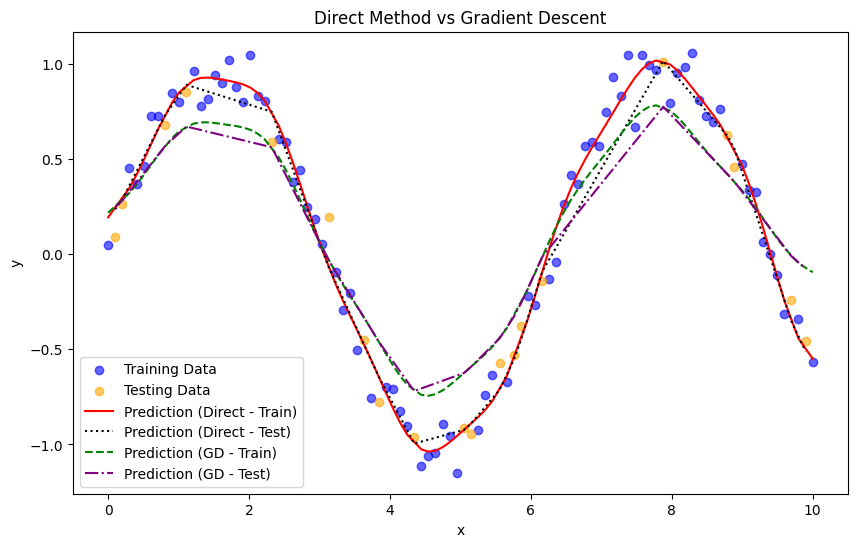

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sine function
def target_function(x):
    return np.sin(x)

# Generate input and output data
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = target_function(x) + np.random.normal(0, 0.1, len(x))

# Split data into training and testing sets
train_size = int(0.8 * len(x))  # 80% for training
indices = np.arange(len(x))
np.random.shuffle(indices)  # Shuffle indices randomly
train_indices = indices[:train_size]
test_indices = indices[train_size:]

x_train, x_test = x[train_indices], x[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

# Gaussian basis function
def gaussian_basis_function(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Set centers and variances
mu = np.linspace(0, 10, 10)  # Centers
sigma = 0.5 * (mu[1] - mu[0])  # Distance between centers

# Create Φ matrix for training and testing data
Phi_train = np.array([gaussian_basis_function(x_train, m, sigma) for m in mu]).T
Phi_test = np.array([gaussian_basis_function(x_test, m, sigma) for m in mu]).T

# Calculate weights using direct method
w_direct = np.linalg.inv(Phi_train.T @ Phi_train) @ Phi_train.T @ y_train

# Predictions (direct method)
y_train_pred_direct = Phi_train @ w_direct
y_test_pred_direct = Phi_test @ w_direct

# Gradient descent for updating weights
def gradient_descent(Phi, y, eta, iterations):
    w = np.zeros(Phi.shape[1])  # Initialize weights to zero
    for _ in range(iterations):
        gradient = Phi.T @ (Phi @ w - y) / len(y)
        w -= eta * gradient
    return w

# Gradient descent settings
eta = 0.01  # Learning rate
iterations = 1000
w_gd = gradient_descent(Phi_train, y_train, eta, iterations)

# Predictions (gradient descent)
y_train_pred_gd = Phi_train @ w_gd
y_test_pred_gd = Phi_test @ w_gd

# Function to calculate MSE
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Calculate MSE for direct method
mse_train_direct = mse(y_train, y_train_pred_direct)
mse_test_direct = mse(y_test, y_test_pred_direct)

# Calculate MSE for gradient descent
mse_train_gd = mse(y_train, y_train_pred_gd)
mse_test_gd = mse(y_test, y_test_pred_gd)

# Print MSE results
print(f"MSE Train (Direct Method): {mse_train_direct:.5f}")
print(f"MSE Test (Direct Method): {mse_test_direct:.5f}")
print(f"MSE Train (Gradient Descent): {mse_train_gd:.5f}")
print(f"MSE Test (Gradient Descent): {mse_test_gd:.5f}")

# Plot predictions with direct method and gradient descent
plt.figure(figsize=(10, 6))

# Training and testing data
plt.scatter(x_train, y_train, label='Training Data', color='blue', alpha=0.6)
plt.scatter(x_test, y_test, label='Testing Data', color='orange', alpha=0.6)

# Predictions with direct method
plt.plot(np.sort(x_train), y_train_pred_direct[np.argsort(x_train)], label='Prediction (Direct - Train)', color='red', linestyle='-')
plt.plot(np.sort(x_test), y_test_pred_direct[np.argsort(x_test)], label='Prediction (Direct - Test)', color='black', linestyle=':')

# Predictions with gradient descent
plt.plot(np.sort(x_train), y_train_pred_gd[np.argsort(x_train)], label='Prediction (GD - Train)', color='green', linestyle='--')
plt.plot(np.sort(x_test), y_test_pred_gd[np.argsort(x_test)], label='Prediction (GD - Test)', color='purple', linestyle='-.')

# Chart settings
plt.legend()
plt.title("Direct Method vs Gradient Descent")
plt.xlabel("x")
plt.ylabel("y")
plt.show()
